   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

C:\Users\User\AppData\Local\Temp\ipykernel_4388\3001535188.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



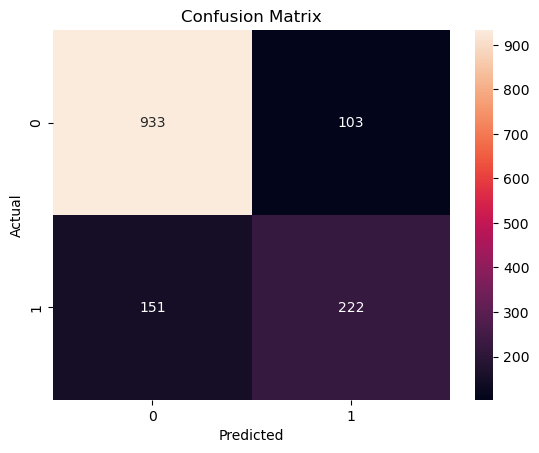

AUC Score: 0.8620609790180837


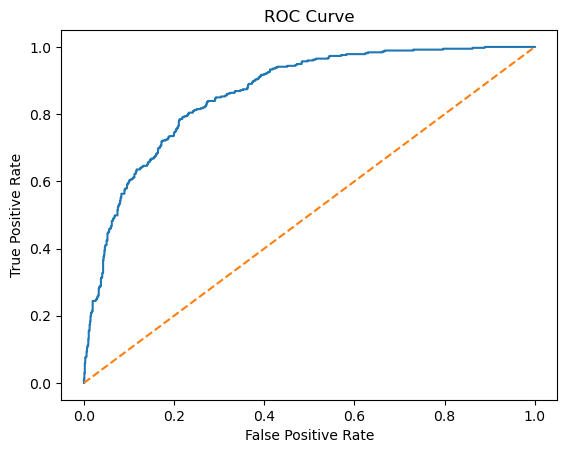


Top Features Influencing Churn:

                           Feature  Coefficient
3                     TotalCharges     0.633747
10     InternetService_Fiber optic     0.622560
23             StreamingMovies_Yes     0.230055
21                 StreamingTV_Yes     0.180115
9                MultipleLines_Yes     0.168187
26            PaperlessBilling_Yes     0.163371
28  PaymentMethod_Electronic check     0.152333
0                    SeniorCitizen     0.058899
8   MultipleLines_No phone service     0.033979
17            DeviceProtection_Yes     0.028432

Final Model Performance:
Accuracy: 0.8197303051809794
AUC Score: 0.8620609790180837


In [8]:
# ================================
# 1. IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


# ================================
# 2. LOAD DATASET
# ================================

# Load dataset (make sure the CSV is in your working directory)
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display first few rows
print(df.head())

# Check dataset structure
print(df.info())


# ================================
# 3. DATA CLEANING
# ================================

# Convert 'TotalCharges' to numeric (it may contain spaces or invalid values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop unnecessary column (customerID has no predictive value)
df.drop('customerID', axis=1, inplace=True)


# ================================
# 4. ENCODE CATEGORICAL VARIABLES
# ================================

# Convert target variable 'Churn' into binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert all other categorical variables using one-hot encoding
df = pd.get_dummies(df, drop_first=True)


# ================================
# 5. DEFINE FEATURES AND TARGET
# ================================

# X = features (input variables)
X = df.drop('Churn', axis=1)

# y = target variable (output)
y = df['Churn']


# ================================
# 6. FEATURE SCALING
# ================================

# Logistic Regression performs better when features are scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ================================
# 7. TRAIN-TEST SPLIT
# ================================

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# ================================
# 8. TRAIN LOGISTIC REGRESSION MODEL
# ================================

# Create model (increase max_iter to ensure convergence)
model = LogisticRegression(max_iter=1000)

# Train model using training data
model.fit(X_train, y_train)


# ================================
# 9. MAKE PREDICTIONS
# ================================

# Predict class labels (0 or 1)
y_pred = model.predict(X_test)

# Predict probabilities (used for ROC curve)
y_prob = model.predict_proba(X_test)[:, 1]


# ================================
# 10. EVALUATE MODEL
# ================================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# Classification report (Precision, Recall, F1-score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ================================
# 11. CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ================================
# 12. ROC CURVE AND AUC SCORE
# ================================

# Calculate AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", roc_auc)

# Generate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


# ================================
# 13. FEATURE IMPORTANCE (COEFFICIENTS)
# ================================

# Get model coefficients (importance of each feature)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort features by importance
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\nTop Features Influencing Churn:\n")
print(coefficients.head(10))


# ================================
# 14. FINAL OUTPUT SUMMARY
# ================================

print("\nFinal Model Performance:")
print("Accuracy:", accuracy)
print("AUC Score:", roc_auc)